In [1]:
# libararies

# Tensorflow 2
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GaussianNoise, Dropout


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten


import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline  

from PIL import Image
import glob

import os
import random
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.models import Model

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.scorecam import Scorecam
from tf_keras_vis.activation_maximization import ActivationMaximization
from tf_keras_vis.activation_maximization.callbacks import Progress
from tf_keras_vis.activation_maximization.input_modifiers import Jitter, Rotate2D
from tf_keras_vis.activation_maximization.regularizers import TotalVariation2D, Norm
from tf_keras_vis.utils.model_modifiers import ExtractIntermediateLayer, ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore


# original (wxh) is (800x600)
w = 224
h = 224

# fix random seed for reproducibility
SEED = 42

# Loading Segmented Leaves

In [2]:
import os, glob
import numpy as np
from PIL import Image

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder)
                  if os.path.splitext(f)[1].lower() in IMG_EXTS)

FOLDERS = {'../olive_leaf_dataset/segmented/train/Healthy': 0,
           '../olive_leaf_dataset/segmented/train/aculus_olearius': 1,
           '../olive_leaf_dataset/segmented/train/olive_peacock_spot': 2}

paths, X, Y = [], [], []
seg_info_rows = []
for folder, label in FOLDERS.items():
    for filename in list_images(folder):
        im = Image.open(filename).convert('RGB').resize((w, h), Image.LANCZOS)
        paths.append(filename)
        X.append(np.array(im))
        Y.append(label)


# Convert to NP array
X = np.array(X)


# reshape to be [samples][channels][width][height]
X = X.reshape(X.shape[0], w, h, 3).astype('float32')

# Normalize the data
X = X /255

Y = np.array(Y)

# randomize the data set - numpy arrays
randomize = np.arange(len(X))
np.random.shuffle(randomize)
X = X[randomize]
Y = Y[randomize]


# one hot encode outputs
Y_orig = Y
Y = to_categorical(Y)
num_classes = Y.shape[1]

print("X:", X.shape, "| Y:", Y.shape, "| per-class:", Y.sum(axis=0))

X: (3003, 224, 224, 3) | Y: (3003, 3) | per-class: [ 899.  761. 1343.]


# Preprocessing

## Leaf Feature Extraction

In this section, texture and color fraction of the leaves are extracted. GLCM is used to get the texture of the leaves.

In [107]:
# import numpy as np
# from skimage.color import rgb2hsv, rgb2gray
# from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
# from skimage.measure import label, regionprops
# from skimage.filters import sobel
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier, export_text
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.inspection import permutation_importance
# from sklearn.metrics import accuracy_score, classification_report

# def leaf_features(img):
#     """
#     img: HxWx3 float in [0,1]  (i.e. your X[i] after /255)
#     returns: dict of named features
#     """
#     img = np.asarray(img, dtype=float)
#     if img.max() > 1.5:                      # tolerate uint8 input too
#         img = img / 255.0
#     R, G, B = img[..., 0], img[..., 1], img[..., 2]
#     hsv = rgb2hsv(img)
#     Hh, S, V = hsv[..., 0] * 360, hsv[..., 1], hsv[..., 2]
#     gray = rgb2gray(img)
#     f = {}
 
#     # ---- leaf mask: drop near-white / near-black background --------------
#     leaf = (V > 0.15) & ~((S < 0.15) & (V > 0.85))
#     if leaf.sum() < 100:                     # fallback if masking fails
#         leaf = np.ones_like(V, dtype=bool)
#     #f["leaf_area_frac"] = leaf.mean()
#     n_leaf = leaf.sum()
 
#     # ---- 1. tissue colour composition (all measured inside the leaf) -----
#     def frac(mask):
#         return (mask & leaf).sum() / n_leaf
 
#     f["frac_green"]  = frac((Hh >= 70) & (Hh < 160) & (S > 0.25))
#     f["frac_yellow"] = frac((Hh >= 40) & (Hh < 70) & (S > 0.25))   # chlorosis
#     f["frac_brown"]  = frac((Hh >= 10) & (Hh < 40) & (S > 0.20) & (V < 0.6))
#     f["frac_dark"]   = frac(V < 0.25)                              # necrosis
#     f["frac_gray"]   = frac(S < 0.20)                              # silvering
 
#     # ---- 2. colour statistics inside the leaf ---------------------------
#     f["mean_hue"] = Hh[leaf].mean()
#     f["std_hue"] = Hh[leaf].std()            # mottling -> high
#     f["mean_sat"] = S[leaf].mean()
#     f["std_sat"] = S[leaf].std()
#     f["mean_val"] = V[leaf].mean()
#     f["std_val"] = V[leaf].std()
#     f["excess_green"] = (2 * G - R - B)[leaf].mean()
#     f["green_minus_red"] = (G - R)[leaf].mean()
 
#     # ---- 3. lesion morphology (the peacock-spot signature) --------------
#     # dark or brown blobs sitting inside otherwise green tissue
#     lesion = leaf & ((V < 0.35) | ((Hh >= 10) & (Hh < 45) & (S > 0.25) & (V < 0.55)))
#     lab = label(lesion)
#     props = [p for p in regionprops(lab) if p.area >= 20]
#     f["lesion_area_frac"] = lesion.sum() / n_leaf
#     f["n_lesions"] = len(props)
#     if props:
#        areas = np.array([p.area for p in props])
#        f["lesion_mean_area"] = areas.mean() / n_leaf
#        f["lesion_max_area"] = areas.max() / n_leaf
#        f["lesion_area_std"] = areas.std() / n_leaf
#        circ = [4 * np.pi * p.area / max(p.perimeter ** 2, 1e-6) for p in props]
#        f["lesion_circularity"] = float(np.mean(circ))
#        f["lesion_eccentricity"] = float(np.mean([p.eccentricity for p in props]))
#     else:
#        for k in ["lesion_mean_area", "lesion_max_area", "lesion_area_std",
#                  "lesion_circularity", "lesion_eccentricity"]:
#            f[k] = 0.0
 
#     # ---- 4. texture: GLCM (roughness / mottling) ------------------------
#     q = (gray * 63).astype(np.uint8)
#     glcm = graycomatrix(q, distances=[1, 3], angles=[0, np.pi / 2],
#                         levels=64, symmetric=True, normed=True)
#     for prop in ["contrast", "homogeneity", "energy", "correlation"]:
#         f[f"glcm_{prop}"] = float(graycoprops(glcm, prop).mean())
 
#     # ---- 5. texture: LBP histogram (surface pattern) --------------------
#     lbp = local_binary_pattern((gray * 255).astype(np.uint8), P=8, R=1,
#                               method="uniform")
#     hist, _ = np.histogram(lbp[leaf], bins=10, range=(0, 10), density=True)
#     for i, v in enumerate(hist):
#        f[f"lbp_{i}"] = float(v)
 
#     # ---- 6. edges (lesion borders, vein prominence) ---------------------
#     edges = sobel(gray)
#     f["edge_mean"] = edges[leaf].mean()
#     f["edge_frac_strong"] = (edges[leaf] > 0.08).mean()
 
#     return f

In [49]:
import numpy as np
from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label, regionprops
from skimage.filters import sobel, gabor
from skimage.filters.rank import entropy as rank_entropy
from skimage.morphology import disk
from scipy.ndimage import uniform_filter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report


def leaf_features(img):
    """
    img: HxWx3 float in [0,1]  (i.e. your X[i] after /255)
    returns: dict of named features
    """
    img = np.asarray(img, dtype=float)
    if img.max() > 1.5:                      # tolerate uint8 input too
        img = img / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    hsv = rgb2hsv(img)
    Hh, S, V = hsv[..., 0] * 360, hsv[..., 1], hsv[..., 2]
    gray = rgb2gray(img)
    f = {}

    # ---- leaf mask: drop near-white / near-black background --------------
    leaf = (V > 0.15) & ~((S < 0.15) & (V > 0.85))
    if leaf.sum() < 100:                     # fallback if masking fails
        leaf = np.ones_like(V, dtype=bool)
    #f["leaf_area_frac"] = leaf.mean()
    n_leaf = leaf.sum()

    # ---- 1. tissue colour composition (all measured inside the leaf) -----
    def frac(mask):
        return (mask & leaf).sum() / n_leaf

    f["frac_green"]  = frac((Hh >= 70) & (Hh < 160) & (S > 0.25))
    f["frac_yellow"] = frac((Hh >= 40) & (Hh < 70) & (S > 0.25))   # chlorosis
    f["frac_brown"]  = frac((Hh >= 10) & (Hh < 40) & (S > 0.20) & (V < 0.6))
    f["frac_dark"]   = frac(V < 0.25)                              # necrosis
    f["frac_gray"]   = frac(S < 0.20)                              # silvering

    # ---- 2. colour statistics inside the leaf ---------------------------
    f["mean_hue"] = Hh[leaf].mean()
    f["std_hue"] = Hh[leaf].std()            # mottling -> high
    f["mean_sat"] = S[leaf].mean()
    f["std_sat"] = S[leaf].std()
    f["mean_val"] = V[leaf].mean()
    f["std_val"] = V[leaf].std()
    f["excess_green"] = (2 * G - R - B)[leaf].mean()
    f["green_minus_red"] = (G - R)[leaf].mean()

    # ---- 3. lesion morphology (the peacock-spot signature) --------------
    # dark or brown blobs sitting inside otherwise green tissue
    lesion = leaf & ((V < 0.35) | ((Hh >= 10) & (Hh < 45) & (S > 0.25) & (V < 0.55)))
    lab = label(lesion)
    props = [p for p in regionprops(lab) if p.area >= 20]
    f["lesion_area_frac"] = lesion.sum() / n_leaf
    f["n_lesions"] = len(props)
    if props:
       areas = np.array([p.area for p in props])
       f["lesion_mean_area"] = areas.mean() / n_leaf
       f["lesion_max_area"] = areas.max() / n_leaf
       f["lesion_area_std"] = areas.std() / n_leaf
       circ = [4 * np.pi * p.area / max(p.perimeter ** 2, 1e-6) for p in props]
       f["lesion_circularity"] = float(np.mean(circ))
       f["lesion_eccentricity"] = float(np.mean([p.eccentricity for p in props]))
    else:
       for k in ["lesion_mean_area", "lesion_max_area", "lesion_area_std",
                 "lesion_circularity", "lesion_eccentricity"]:
           f[k] = 0.0

    # ---- 4. texture: GLCM (roughness / mottling) ------------------------
    q = (gray * 63).astype(np.uint8)
    glcm = graycomatrix(q, distances=[1, 3], angles=[0, np.pi / 2],
                        levels=64, symmetric=True, normed=True)
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        f[f"glcm_{prop}"] = float(graycoprops(glcm, prop).mean())

    # ---- 5. texture: LBP histogram (surface pattern) --------------------
    lbp = local_binary_pattern((gray * 255).astype(np.uint8), P=8, R=1,
                              method="uniform")
    hist, _ = np.histogram(lbp[leaf], bins=10, range=(0, 10), density=True)
    for i, v in enumerate(hist):
       f[f"lbp_{i}"] = float(v)
    # derived scalar: fraction of leaf covered by "uniform" LBP patterns.
    # High = smooth healthy-looking cuticle. A drop signals the fine
    # stippled/russeted micro-texture caused by aculus_olearius mite
    # feeding, even when color features (frac_*, mean_hue etc.) look
    # similar to healthy.
    f["lbp_uniform_frac"] = float(hist[:9].sum())

    # ---- 6. edges (lesion borders, vein prominence) ---------------------
    edges = sobel(gray)
    f["edge_mean"] = edges[leaf].mean()
    f["edge_frac_strong"] = (edges[leaf] > 0.08).mean()

    # ---- 7. local gloss (specular) variance ------------------------------
    # healthy waxy cuticle -> localized bright specular highlights -> high
    # local variance in V. Russeted/silvered tissue from mite damage is
    # duller and flatter, so this variance drops even when mean brightness
    # is unchanged. This targets healthy vs aculus_olearius specifically.
    win = 5
    v_mean_local = uniform_filter(V, size=win)
    v_sq_mean_local = uniform_filter(V**2, size=win)
    v_local_var = v_sq_mean_local - v_mean_local**2
    f["v_local_var_mean"] = float(v_local_var[leaf].mean())
    f["v_local_var_std"] = float(v_local_var[leaf].std())
    f["frac_flat_gloss"] = float(
        (v_local_var[leaf] < np.percentile(v_local_var[leaf], 20)).mean()
    )

    # ---- 8. local saturation variance (desaturation patchiness) ---------
    s_mean_local = uniform_filter(S, size=win)
    s_sq_mean_local = uniform_filter(S**2, size=win)
    s_local_var = s_sq_mean_local - s_mean_local**2
    f["s_local_var_mean"] = float(s_local_var[leaf].mean())

    # ---- 9. entropy (textural randomness) --------------------------------
    # catches "noisier surface than healthy" even when mean color unchanged
    ent = rank_entropy((gray * 255).astype(np.uint8), disk(3))
    f["entropy_mean"] = float(ent[leaf].mean())
    f["entropy_std"] = float(ent[leaf].std())

    # ---- 10. Gabor filter bank (oriented fine texture) -------------------
    # fine-frequency, multi-orientation texture energy; anisotropy (std
    # across orientations) helps separate randomly-stippled mite damage
    # from the more directional vein/lesion patterns of peacock spot
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    gabor_energies = []
    for theta in thetas:
        real, imag = gabor(gray, frequency=0.3, theta=theta)
        mag = np.sqrt(real**2 + imag**2)
        gabor_energies.append(mag[leaf].mean())
    f["gabor_energy_mean"] = float(np.mean(gabor_energies))
    f["gabor_energy_std"] = float(np.std(gabor_energies))

    # ---- 11. fine GLCM on saturation channel ------------------------------
    # texture computed on S rather than gray -> catches patchy desaturation
    # that luminance-based GLCM (block 4) can miss
    s_q = (S * 63).astype(np.uint8)
    glcm_s = graycomatrix(s_q, distances=[1], angles=[0, np.pi/2],
                           levels=64, symmetric=True, normed=True)
    f["glcm_sat_contrast"] = float(graycoprops(glcm_s, "contrast").mean())
    f["glcm_sat_homogeneity"] = float(graycoprops(glcm_s, "homogeneity").mean())

    return f


In [48]:
X.shape

(3003, 224, 224, 3)

In [50]:
def build_matrix(images):
    # print(type(images))
    # print(images.shape)
    dicts = [leaf_features(im) for im in images]
    names = list(dicts[0].keys())
    return np.array([[d[k] for k in names] for d in dicts]), names

In [42]:
X.shape

(3003, 224, 224, 3)

In [51]:
import pandas as pd

X_feat, feature_names = build_matrix(X)

CLASS_NAMES = {0: 'Healthy', 1: 'aculus_olearius', 2: 'olive_peacock_spot'}

df = pd.DataFrame(X_feat, columns=feature_names)
df.insert(0, 'file',  [os.path.basename(p) for p in paths])
df.insert(1, 'class', [CLASS_NAMES[v] for v in Y_orig])
df.insert(2, 'label', Y_orig)

print(df.shape)      # (2720, 40)
df.head()

(3003, 50)


,file,class,label,frac_green,frac_yellow,frac_brown,frac_dark,frac_gray,mean_hue,std_hue,...,v_local_var_mean,v_local_var_std,frac_flat_gloss,s_local_var_mean,entropy_mean,entropy_std,gabor_energy_mean,gabor_energy_std,glcm_sat_contrast,glcm_sat_homogeneity
0,A163_leaf00.png,olive_peacock_spot,2,0.980813,0.000000,0.000000,0.051502,0.010351,76.063349,3.393783,...,0.005077,0.009919,0.199950,0.009811,3.932339,0.314122,0.005306,0.002978,10.843990,0.933829
1,A299_leaf00.png,olive_peacock_spot,2,0.236912,0.482157,0.138815,0.191165,0.065241,66.092222,39.163203,...,0.006231,0.011841,0.199969,0.011916,4.098242,0.271460,0.005915,0.001912,10.913297,0.900520
2,A310_leaf00.png,aculus_olearius,1,0.939873,0.021342,0.000000,0.042274,0.024010,80.438376,5.191597,...,0.011506,0.022220,0.200082,0.017455,4.268974,0.244549,0.008132,0.002938,17.308576,0.911452
3,A319_leaf00.png,olive_peacock_spot,2,0.557768,0.311183,0.009493,0.012271,0.072702,76.583470,18.372957,...,0.007276,0.014222,0.200046,0.006004,3.828251,0.346335,0.005965,0.004511,9.801950,0.942985
4,A442_leaf00.png,Healthy,0,0.808310,0.090674,0.043583,0.269252,0.046907,73.577909,17.780730,...,0.006624,0.015611,0.200000,0.008872,4.065438,0.296713,0.006025,0.002479,7.729620,0.911811


In [52]:
df.to_csv('leaf_features_v1.csv', index=False)

# Train model - Decision Tree

In [88]:
Xtr, Xte, ytr, yte = train_test_split(X_feat, Y_orig, test_size=0.3,random_state=42)

clf3 = DecisionTreeClassifier(max_depth=5, class_weight="balanced",random_state=42).fit(Xtr, ytr)
print(classification_report(yte, clf3.predict(Xte),
                            target_names=["Healthy", "aculus", "peacock"]))

              precision    recall  f1-score   support

     Healthy       0.62      0.71      0.67       262
      aculus       0.64      0.68      0.66       244
     peacock       0.83      0.72      0.77       395

    accuracy                           0.71       901
   macro avg       0.70      0.70      0.70       901
weighted avg       0.72      0.71      0.71       901



In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X_feat, Y_orig, test_size=0.3,random_state=42)

clf8 = DecisionTreeClassifier(max_depth=8, class_weight="balanced",random_state=42).fit(Xtr, ytr)
print(classification_report(yte, clf8.predict(Xte),
                            target_names=["Healthy", "aculus", "peacock"]))

              precision    recall  f1-score   support

     Healthy       0.68      0.77      0.72       262
      aculus       0.70      0.72      0.71       244
     peacock       0.85      0.75      0.80       395

    accuracy                           0.75       901
   macro avg       0.74      0.75      0.74       901
weighted avg       0.76      0.75      0.75       901



In [103]:
Xtr, Xte, ytr, yte = train_test_split(X_feat, Y_orig, test_size=0.3,random_state=42)

clf = DecisionTreeClassifier(max_depth=8, min_samples_leaf=3, class_weight="balanced",random_state=42).fit(Xtr, ytr)
print(classification_report(yte, clf.predict(Xte),
                            target_names=["Healthy", "aculus", "peacock"]))

              precision    recall  f1-score   support

     Healthy       0.68      0.76      0.72       262
      aculus       0.68      0.73      0.70       244
     peacock       0.85      0.75      0.80       395

    accuracy                           0.75       901
   macro avg       0.74      0.75      0.74       901
weighted avg       0.76      0.75      0.75       901



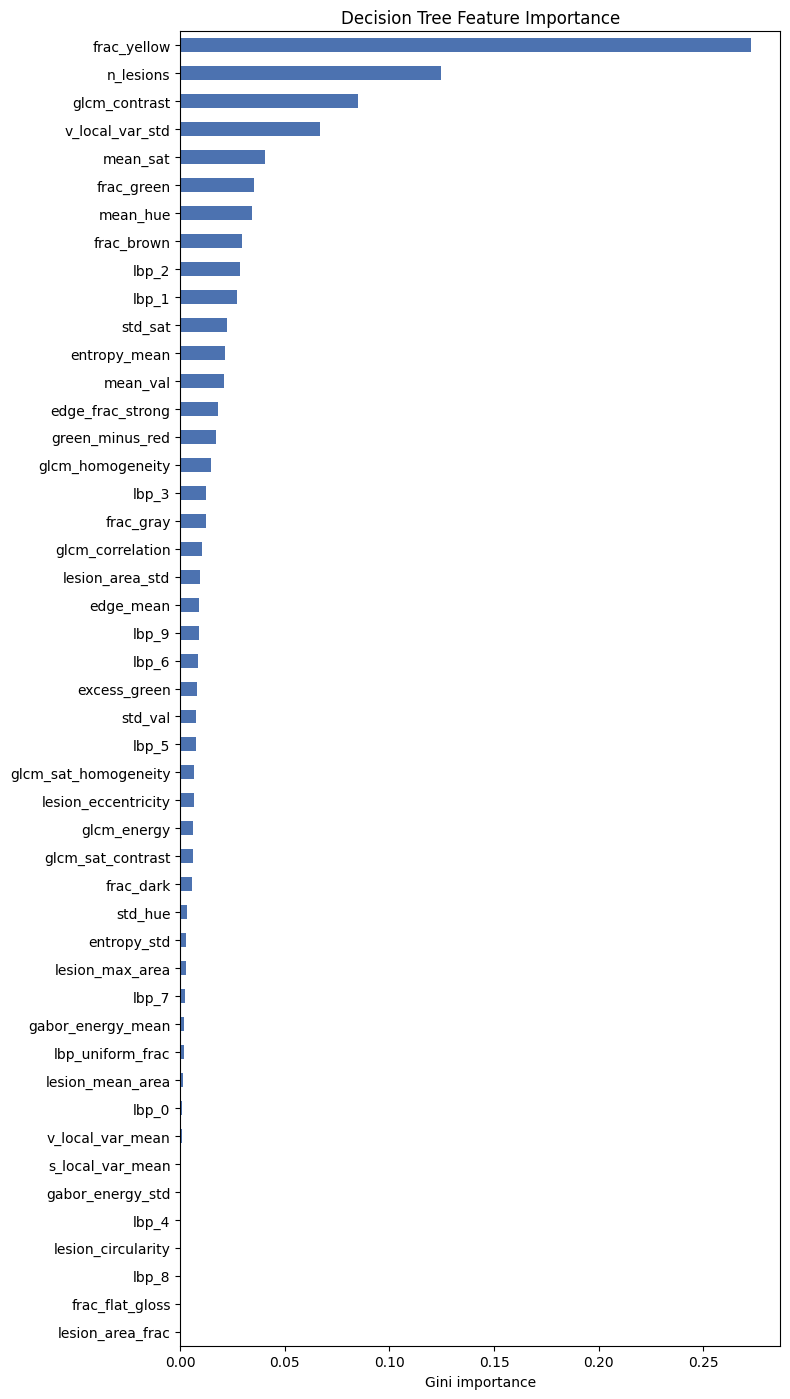

Used 47 of 47 features
lesion_eccentricity    0.006377
glcm_energy            0.005962
glcm_sat_contrast      0.005930
frac_dark              0.005429
std_hue                0.003291
entropy_std            0.002880
lesion_max_area        0.002487
lbp_7                  0.002288
gabor_energy_mean      0.001963
lbp_uniform_frac       0.001698
lesion_mean_area       0.001149
lbp_0                  0.001023
v_local_var_mean       0.000825
s_local_var_mean       0.000474
gabor_energy_std       0.000261
frac_flat_gloss        0.000000
lbp_4                  0.000000
lesion_circularity     0.000000
lbp_8                  0.000000
lesion_area_frac       0.000000
dtype: float64


In [104]:
importances = pd.Series(clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

# drop zero-importance features (tree didn't use them at all) for a cleaner plot
# importances_nonzero = importances[importances > 0]
importances_nonzero = importances

plt.figure(figsize=(8, max(4, len(importances_nonzero) * 0.3)))
importances_nonzero.sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Gini importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(f"Used {len(importances_nonzero)} of {len(importances)} features")
print(importances_nonzero.tail(20))  # top 10, since sorted ascending for the barh

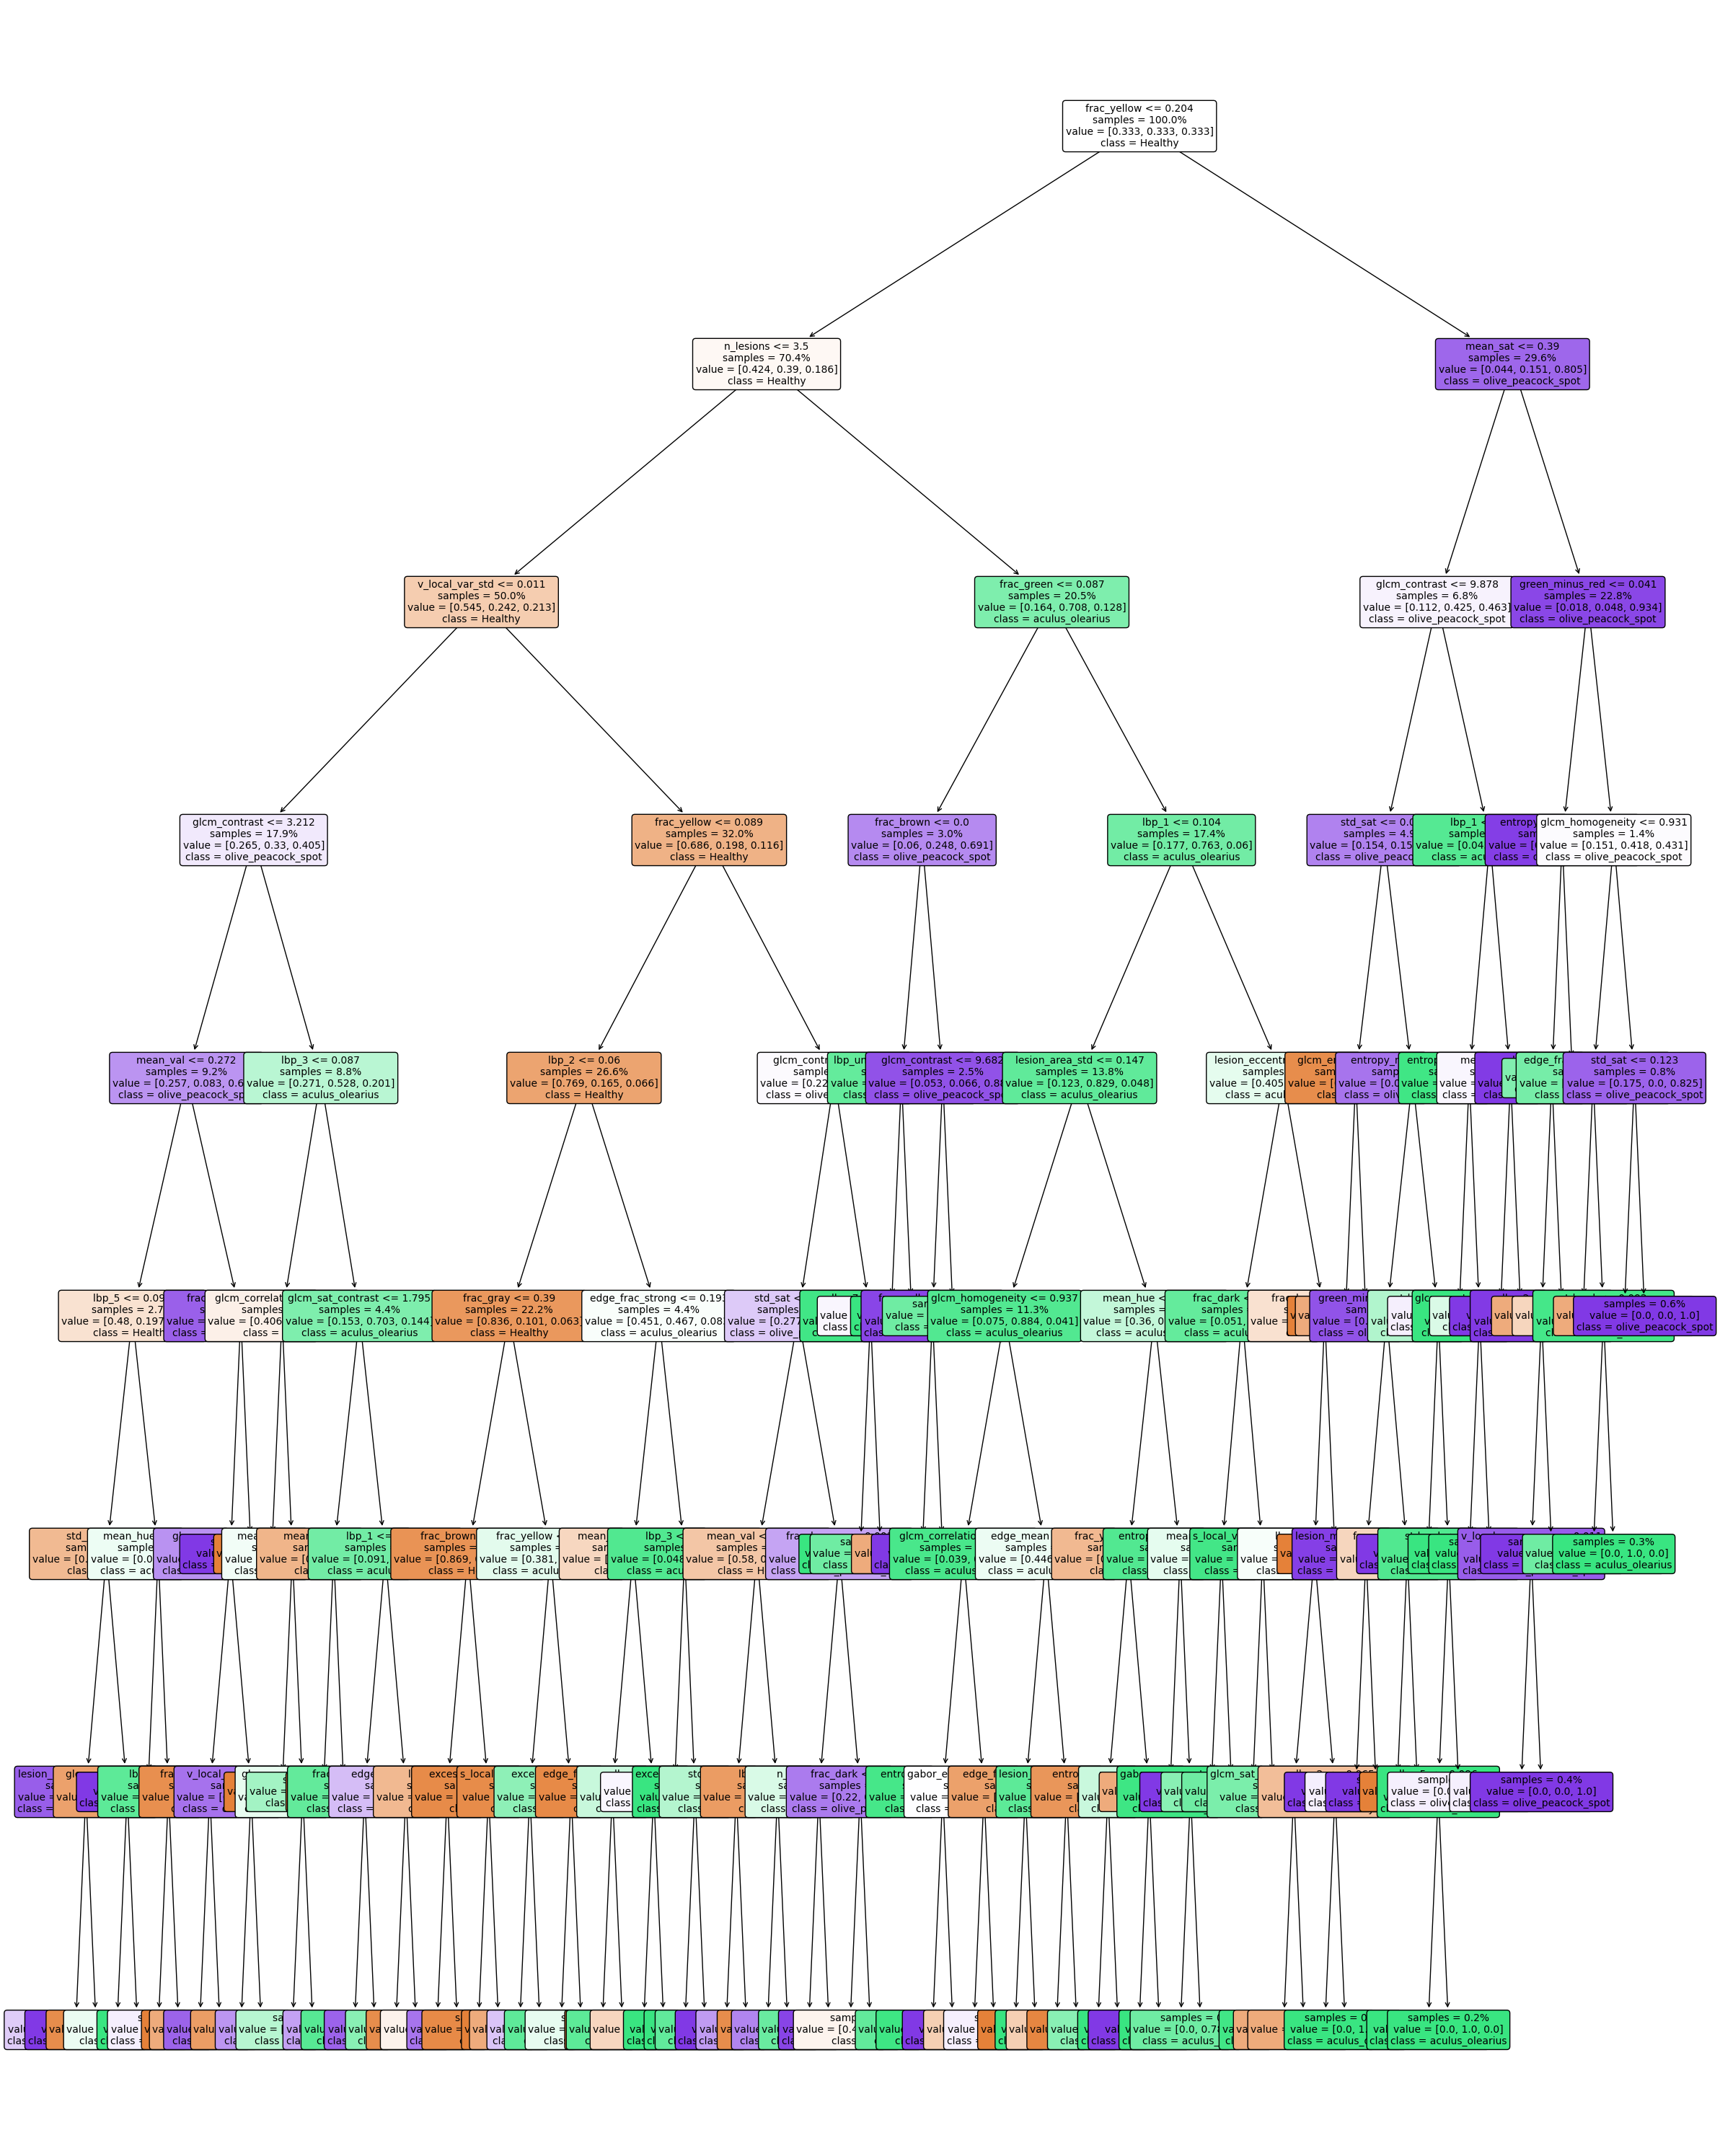

In [105]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 30))
plot_tree(clf,
          feature_names=feature_names,
          class_names=["Healthy", "aculus_olearius", "olive_peacock_spot"],
          filled=True, rounded=True,
          impurity=False,        # hide gini
          proportion=True,       # percentages, clearer with class_weight="balanced"
          fontsize=10, ax=ax)
plt.tight_layout()
plt.savefig("olive_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [108]:
# pip install supertree
from supertree import SuperTree

# clf = your trained DecisionTreeClassifier(max_depth=10, ...)
# X_train, y_train = your training data (SuperTree wants the data too,
# not just the fitted model, so it can show sample counts/distributions at each node)

class_names = ["healthy", "aculus_olearius", "peacock_spot"]  # match your label encoding order

st = SuperTree(clf, Xtr, ytr, feature_names, class_names)

# Option A: render inline in a Jupyter notebook (interactive widget)
st.show_tree()

# Option B: save as a standalone HTML file you can open in a browser
# or share with your group / include in the report
st.save_html("decision_tree.html")

HTML saved to decision_tree.html


In [109]:
# Saving the model
import joblib
joblib.dump(clf, 'leaf_tree.joblib')

['leaf_tree.joblib']